In [33]:
import sys
sys.path.append("./helper")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec

from true_loss_funcs import generate_neg_log_likelihood_pitzer_4
import pickle
from tqdm import tqdm

from scipy.integrate import odeint
from transmission_models import pitzer_sirsirsirs

## 4 unknown parameters

In [34]:
rng = np.random.default_rng(123)
loss_fn = generate_neg_log_likelihood_pitzer_4(rng)

beta = 23.25 * 4.3 / 2.9e7
seasonality = 0.055
phi = 0.636
h = 0.041
parms = np.array([beta*1e+5, seasonality, phi, h])
true_loss = loss_fn(parms)

In [35]:
with open("pitzer_results/pitzer_4_unbounded_nm_nm_n_calls.pkl", "rb") as f:
    nm_nm_n_calls = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_nm_nm_times.pkl", "rb") as f:
    nm_nm_times = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_nm_nm_best_x.pkl", "rb") as f:
    nm_nm_best_x = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_nm_nm_best_loss.pkl", "rb") as f:
    nm_nm_best_loss = pickle.load(f)

with open("pitzer_results/pitzer_4_unbounded_rf_nm_n_calls.pkl", "rb") as f:
    rf_nm_n_calls = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_rf_nm_times.pkl", "rb") as f:
    rf_nm_times = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_rf_nm_best_x.pkl", "rb") as f:
    rf_nm_best_x = pickle.load(f)
with open("pitzer_results/pitzer_4_unbounded_rf_nm_best_loss.pkl", "rb") as f:
    rf_nm_best_loss = pickle.load(f)

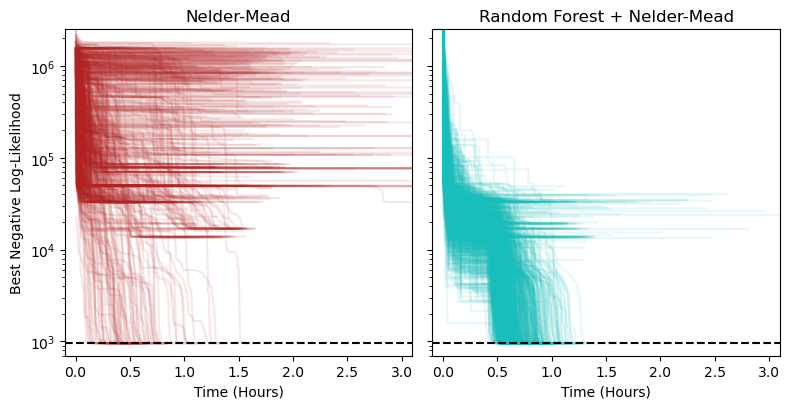

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4.2), sharex=True, sharey=True)

n_runs = 900
alpha = 0.1

# Nelder-Mead + Nelder-Mead
id = 0
for i in range(n_runs):
    ax[id].plot(np.array(nm_nm_times[i])/3600, nm_nm_best_loss[i], color="#b22222", alpha=alpha)

ax[id].axhline(y=true_loss, color = "black", linestyle = "--", label = "True Loss")
ax[id].set_xlim(-0.1, 3.1)
ax[id].set_ylim(7*1e2, 2.5*1e6)
ax[id].set_yscale("log")
ax[id].set_xlabel("Time (Hours)")
ax[id].set_ylabel("Best Negative Log-Likelihood")
ax[id].set_title("Nelder-Mead")

# Random Forest + Nelder-Mead
id = 1
for i in range(n_runs):
    ax[id].plot(np.array(rf_nm_times[i])/3600, rf_nm_best_loss[i], color="#17BEBB", alpha=alpha)

ax[id].axhline(y=true_loss, color = "black", linestyle = "--", label = "True Loss")
ax[id].set_yscale("log")
ax[id].set_xlabel("Time (Hours)")
ax[id].set_title("Random Forest + Nelder-Mead")

fig.tight_layout()
plt.savefig("figures/S2 Fig.tif", dpi=300, bbox_inches="tight")

In [15]:
def get_H_4(parms):
    # Parameters
    w0 = (1/3)
    w1 = (1/9) 
    w2 = (1/12)
    g1 = 4.3
    g2 = 8.6
    s1 = 0.62
    s2 = 0.35
    p2 = 0.5
    pA = 0.1
    d1 = 0.11
    d2 = 0.029

    beta = parms[0]/1e5
    seasonality = parms[1]
    phi = parms[2]
    h = parms[3]

    T = 12*50

    # starting proportion of people in each age class
    agep = np.concatenate(((1/960)*np.ones(12), (1/80)*np.ones(4), np.array([1/16, 1/8, 1/4, 1/4, 1/4])))
    al = len(agep)
    # aging rates
    u = np.concatenate((1*np.ones(12), (1/12)*np.ones(4), np.array([1/(12*5), 1/120, 1/240, 1/240, 1/126])))
    # age-specific susceptibility
    c = np.concatenate((1.555*np.ones(12), np.array([2.312,1.738]), np.ones(7)))

    # initial population size
    N = 2.9e7

    # initial state
    St0 = np.concatenate((N/960*np.ones(1), np.zeros(al-1), N*agep - np.ones(al), np.ones(al), np.zeros(7*al)))

    args = (w0, w1, w2, g1, g2, s1, s2, p2, pA, beta, seasonality, phi)
    result = odeint(pitzer_sirsirsirs, St0, np.arange(0,T), args = args)

    betas = beta*(1+seasonality*np.cos(2*np.pi*(np.arange(0,T)/12-phi)))
    betas = betas.reshape((600, 1))
    num_I = np.sum(result[:,2*al:3*al]+p2*result[:,5*al:6*al]+pA*result[:,8*al:9*al], axis=1).reshape((600, 1)) 

    foi = betas*num_I*c
    H = h*d1*foi*result[:,al:2*al] + h*d2*s1*foi*result[:,4*al:5*al]
    H = np.sum(H, axis=1)

    return H

In [16]:
def sample_best_fixed_time_budget(all_times, all_best_loss, all_best_x, budget):

    cur_best_loss = np.inf
    cur_best_x = []
    reached_budget = False

    # remove placeholder values at the end
    final_losses = [np.inf]
    final_times = [0]
    final_best_x = [[]]

    while True:

        # randomly select a run
        idx = np.random.randint(0, len(all_times))
        times = all_times[idx]
        best_loss = all_best_loss[idx]
        best_x = all_best_x[idx]

        prev_time = 0

        for i in range(len(times)):

            # add time
            time_inc = times[i] - prev_time
            final_times.append(final_times[-1] + time_inc)
            prev_time = times[i]

            # check if found better answer
            if best_loss[i] < cur_best_loss:
                cur_best_loss = best_loss[i]
                cur_best_x = best_x[i]
            # add current best loss and best x
            final_losses.append(cur_best_loss)
            final_best_x.append(cur_best_x)
            
            # check if reached max budget
            if final_times[-1] >= budget:
                reached_budget = True
                break
    
        # exit if reached max budget
        if reached_budget:
            break

    # delete placeholder values
    del final_losses[0]
    del final_times[0]
    del final_best_x[0]

    return np.array(final_losses), np.array(final_times), np.array(final_best_x)

In [17]:
all_nm_nm_losses = []
all_nm_nm_times = []
all_nm_nm_best_x = []
all_rf_nm_losses = []
all_rf_nm_times = []
all_rf_nm_best_x = []

for i in tqdm(range(2000)):

    losses, times, best_x = sample_best_fixed_time_budget(nm_nm_times, nm_nm_best_loss, nm_nm_best_x, 10*3600)
    all_nm_nm_losses.append(losses)
    all_nm_nm_times.append(times)
    all_nm_nm_best_x.append(best_x)

    losses, times, best_x = sample_best_fixed_time_budget(rf_nm_times, rf_nm_best_loss, rf_nm_best_x, 10*3600)
    all_rf_nm_losses.append(losses)
    all_rf_nm_times.append(times)
    all_rf_nm_best_x.append(best_x)

100%|██████████| 2000/2000 [00:12<00:00, 161.16it/s]


In [18]:
# get time series overlaps
time_min = max(max(times[0] for times in all_nm_nm_times), max(times[0] for times in all_rf_nm_times))
time_max = min(min(times[-1] for times in all_nm_nm_times), min(times[-1] for times in all_rf_nm_times))
time_grid = np.arange(time_min, time_max + 1e-6, 10.0)

# interpolate each trajectory - NM+NM
all_nm_nm_interp_losses = []
for time, loss in zip(all_nm_nm_times, all_nm_nm_losses):
    interp_losses = np.interp(time_grid, time, loss, left=np.nan, right=np.nan)
    all_nm_nm_interp_losses.append(interp_losses)
all_nm_nm_interp_losses = np.array(all_nm_nm_interp_losses)

# interpolate each trajectory - RF+NM
all_rf_nm_interp_losses = []
for time, loss in zip(all_rf_nm_times, all_rf_nm_losses):
    interp_losses = np.interp(time_grid, time, loss, left=np.nan, right=np.nan)
    all_rf_nm_interp_losses.append(interp_losses)
all_rf_nm_interp_losses = np.array(all_rf_nm_interp_losses)

# compute medians + quantiles
nm_nm_median = np.nanmedian(all_nm_nm_interp_losses, axis=0)
nm_nm_q_low, nm_nm_q_high = np.nanquantile(all_nm_nm_interp_losses, [0.025, 0.975], axis=0)
rf_nm_median = np.nanmedian(all_rf_nm_interp_losses, axis=0)
rf_nm_q_low, rf_nm_q_high = np.nanquantile(all_rf_nm_interp_losses, [0.025, 0.975], axis=0)

In [20]:
def success_prop(sampled_losses, true_loss):
    return np.sum(sampled_losses < true_loss) / len(sampled_losses)

nm_nm_success_prop = [success_prop(losses, true_loss) for losses in all_nm_nm_interp_losses.T]
rf_nm_success_prop = [success_prop(losses, true_loss) for losses in all_rf_nm_interp_losses.T]

In [21]:
# 2-, 4-, 8-hour increments

n_samples = 100

budgets = np.array([2, 4, 8]) * 3600
all_nm_nm_sampled_x = []
all_rf_nm_sampled_x = []

for i in range(len(budgets)):

    budget = budgets[i]
    nm_nm_sampled_x = []
    rf_nm_sampled_x = []
    
    for j in range(n_samples):

        # FOR NM-NM
        # randomly select a run
        run_idx = np.random.randint(0, len(all_nm_nm_times))
        cur_times = all_nm_nm_times[run_idx]
        cur_best_x = all_nm_nm_best_x[run_idx]
        
        # get index of time closest to current budget
        time_idx = np.argmin(np.abs(cur_times - budget))
        # get the best corresponding x value
        nm_nm_sampled_x.append(cur_best_x[time_idx])

        # FOR RF-NM
        # randomly select a run
        run_idx = np.random.randint(0, len(all_rf_nm_times))
        cur_times = all_rf_nm_times[run_idx]
        cur_best_x = all_rf_nm_best_x[run_idx]
        
        # get index of time closest to current budget
        time_idx = np.argmin(np.abs(cur_times - budget))
        # get the best corresponding x value
        rf_nm_sampled_x.append(cur_best_x[time_idx])

    all_nm_nm_sampled_x.append(nm_nm_sampled_x)
    all_rf_nm_sampled_x.append(rf_nm_sampled_x)

all_nm_nm_sampled_x = np.array(all_nm_nm_sampled_x)
all_rf_nm_sampled_x = np.array(all_rf_nm_sampled_x)

In [22]:
# generate model incidences

nm_nm_total_incs = []
for col in range(len(all_nm_nm_sampled_x)):
    cur_total_incs = []
    cur_xs = all_nm_nm_sampled_x[col]
    for i in tqdm(range(n_samples)):
        cur_x = cur_xs[i]
        total_incs = get_H_4(cur_x)
        cur_total_incs.append(total_incs)
    nm_nm_total_incs.append(cur_total_incs)

rf_nm_total_incs = []
for col in range(len(all_rf_nm_sampled_x)):
    cur_total_incs = []
    cur_xs = all_rf_nm_sampled_x[col]
    for i in tqdm(range(n_samples)):
        cur_x = cur_xs[i]
        total_incs = get_H_4(cur_x)
        cur_total_incs.append(total_incs)
    rf_nm_total_incs.append(cur_total_incs)

  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Philip Lee\AppData\Local\Temp\ipykernel_33556\1556004280.py:37: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  result = odeint(pitzer_sirsirsirs, St0, np.arange(0,T), args = args)
100%|██████████| 100/100 [22:18<00:00, 13.39s/it]


In [25]:
# Parameters
w0 = (1/3)
w1 = (1/9) 
w2 = (1/12)
g1 = 4.3
g2 = 8.6
s1 = 0.62
s2 = 0.35
p2 = 0.5
pA = 0.1
d1 = 0.11
d2 = 0.029

beta = 23.25 * 4.3 / 2.9e7
seasonality = 0.055
phi = 0.636
h = 0.041

T = 12*50

# starting proportion of people in each age class
agep = np.concatenate(((1/960)*np.ones(12), (1/80)*np.ones(4), np.array([1/16, 1/8, 1/4, 1/4, 1/4])))
al = len(agep)
# aging rates
u = np.concatenate((1*np.ones(12), (1/12)*np.ones(4), np.array([1/(12*5), 1/120, 1/240, 1/240, 1/126])))
# age-specific susceptibility
c = np.concatenate((1.555*np.ones(12), np.array([2.312,1.738]), np.ones(7)))

# initial population size
N = 2.9e7

# initial state
St0 = np.concatenate((N/960*np.ones(1), np.zeros(al-1), N*agep - np.ones(al), np.ones(al), np.zeros(7*al)))


args = (w0, w1, w2, g1, g2, s1, s2, p2, pA, beta, seasonality, phi)
result = odeint(pitzer_sirsirsirs, St0, np.arange(0,T), args = args)

betas = beta*(1+seasonality*np.cos(2*np.pi*(np.arange(0,T)/12-phi)))
betas = betas.reshape((600, 1))
num_I = np.sum(result[:,2*al:3*al]+p2*result[:,5*al:6*al]+pA*result[:,8*al:9*al], axis=1).reshape((600, 1)) 

foi = betas*num_I*c
H = h*d1*foi*result[:,al:2*al] + h*d2*s1*foi*result[:,4*al:5*al]
H = np.sum(H, axis=1)

# simulate some data
rng = np.random.default_rng(123)
obs_H = rng.poisson(H)

C:\Users\Philip Lee\AppData\Local\Temp\ipykernel_33556\120215803.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


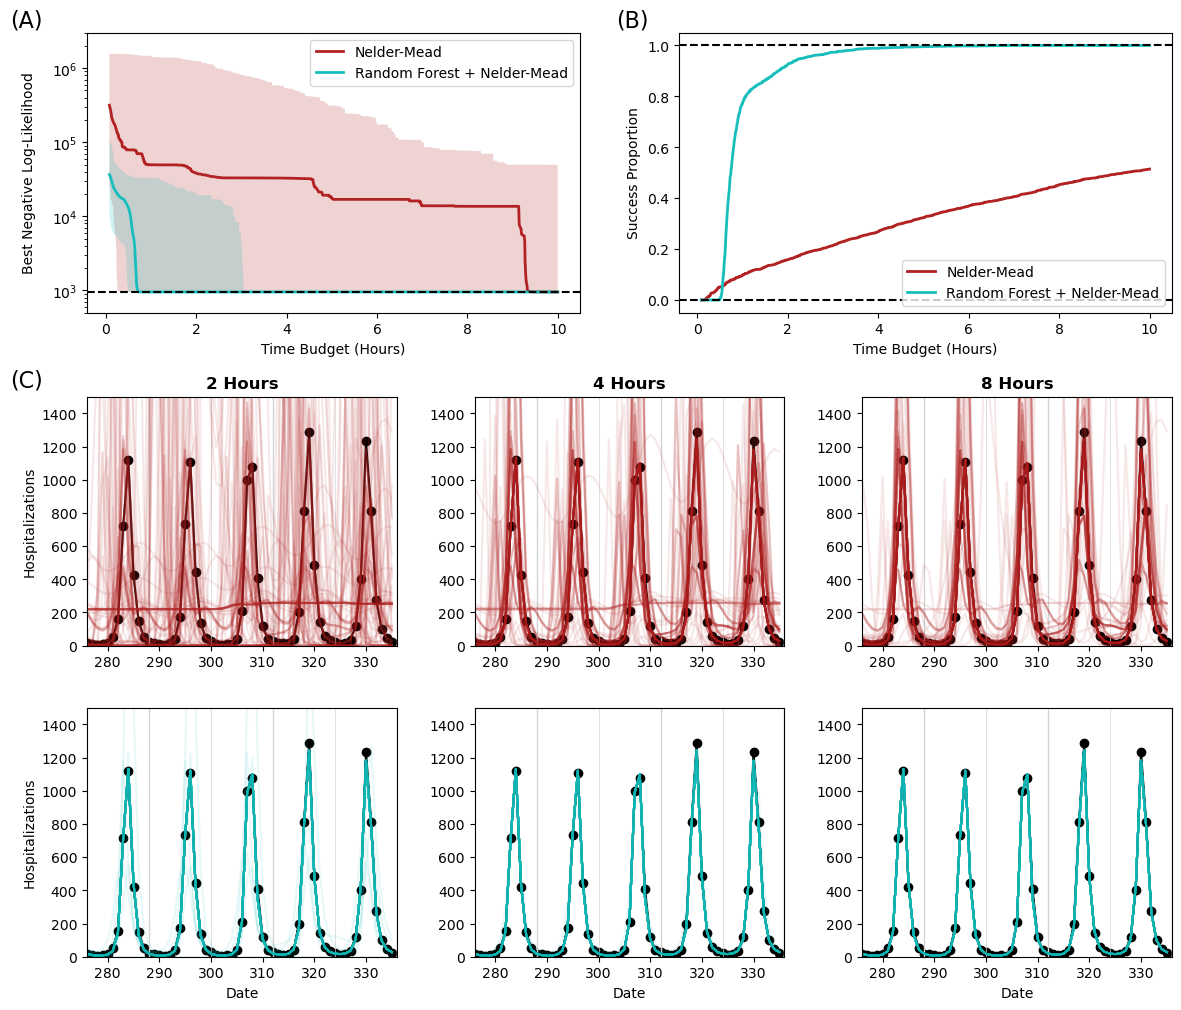

In [37]:
fig = plt.figure(figsize=(14, 12))

# 2 rows, row heights = [1, 2]
gs = GridSpec(
    2, 2,
    height_ratios=[1, 2],
    hspace=0.2,
    wspace=0.2
)

# PLOT A
axA = fig.add_subplot(gs[0, 0])

alpha = 0.2
linewidth = 2

# Nelder-Mead + Nelder-Mead
axA.plot(time_grid/3600, nm_nm_median, color="#b22222", linewidth=linewidth, label="Nelder-Mead")
axA.fill_between(time_grid/3600, nm_nm_q_low, nm_nm_q_high, color="#b22222", alpha=alpha, edgecolor=None)

# Random Forest + Nelder-Mead
axA.plot(time_grid/3600, rf_nm_median, color="#17BEBB", linewidth=linewidth, label="Random Forest + Nelder-Mead")
axA.fill_between(time_grid/3600, rf_nm_q_low, rf_nm_q_high, color="#17BEBB", alpha=alpha, edgecolor=None)

axA.axhline(y=true_loss, color = "black", linestyle = "--")

axA.set_ylim(500, 3*10**6)
axA.set_xlabel("Time Budget (Hours)")
axA.set_ylabel("Best Negative Log-Likelihood")
axA.set_yscale("log")
axA.legend(loc="upper right")

# PLOT B (top-right)
axB = fig.add_subplot(gs[0, 1])

nm_nm_success_prop = [success_prop(losses, true_loss) for losses in all_nm_nm_interp_losses.T]
rf_nm_success_prop = [success_prop(losses, true_loss) for losses in all_rf_nm_interp_losses.T]

linewidth = 2

# Nelder-Mead + Nelder-Mead
axB.plot(time_grid/3600, nm_nm_success_prop, color="#b22222", linewidth=linewidth, label="Nelder-Mead")
# Random Forest + Nelder-Mead
axB.plot(time_grid/3600, rf_nm_success_prop, color="#17BEBB", linewidth=linewidth, label="Random Forest + Nelder-Mead")

axB.axhline(y=0.0, color = "black", linestyle = "--")
axB.axhline(y=1.0, color = "black", linestyle = "--")

axB.set_xlabel("Time Budget (Hours)")
axB.set_ylabel("Success Proportion")
axB.legend()

# PLOT C (bottom, spans both columns)
axC = []

# create a 2x3 grid inside the big panel
inner_gs = GridSpecFromSubplotSpec(
    2, 3,
    subplot_spec=gs[1, :],
    wspace=0.25,
    hspace=0.25
)

# create all 6 subplots
for r in range(2):
    row_axes = []
    for c in range(3):
        row_axes.append(fig.add_subplot(inner_gs[r, c]))
    axC.append(row_axes)

alpha = 0.1
n_yrs = 11

for row, total_incs in enumerate([nm_nm_total_incs, rf_nm_total_incs]):
    for col in range(3):
        ax_cur = axC[row][col]

        # observed
        ax_cur.plot(np.arange(T)[12*25-24:T-24*n_yrs], 
                    obs_H[12*25-24:T-24*n_yrs], 
                    label="Observed Data", color="black", marker="o")

        # vertical lines
        for i in range(T//12 + 1):
            ax_cur.axvline(x=12*i, color='lightgray', linewidth=0.5)
            if i % 2 == 0:
                ax_cur.axvline(x=12*i, color='lightgray', linewidth=1)

        # model fits
        for incs in total_incs[col]:
            ax_cur.plot(np.arange(T)[12*25-24:T-24*n_yrs], 
                        incs[12*25-24:T-24*n_yrs],
                        alpha=alpha, 
                        color=["#b22222", "#17BEBB"][row])

        ax_cur.set_xlim(12*25-24, T-24*n_yrs)
        ax_cur.set_ylim(0, 1500)

        # labels
        if row == 1:
            ax_cur.set_xlabel("Date")
        if col == 0:
            ax_cur.set_ylabel("Hospitalizations")

        if row == 0 and col == 0:
            ax_cur.set_title("2 Hours", fontweight="bold")
        if row == 0 and col == 1:
            ax_cur.set_title("4 Hours", fontweight="bold")
        if row == 0 and col == 2:
            ax_cur.set_title("8 Hours", fontweight="bold")

fig.text(0.07, 0.89, "(A)", fontsize=16, va="center")
fig.text(0.503, 0.89, "(B)", fontsize=16, va="center")
fig.text(0.07, 0.59, "(C)", fontsize=16, va="center")

fig.align_ylabels([axA] + [axC[0][0], axC[1][0]])
fig.tight_layout()

plt.savefig("figures/Fig5.tif", dpi=300, bbox_inches="tight")

## 6 unknown parameters

In [38]:
with open("pitzer_results/pitzer_6_unbounded_nm_nm_n_calls.pkl", "rb") as f:
    nm_nm_n_calls = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_nm_nm_times.pkl", "rb") as f:
    nm_nm_times = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_nm_nm_best_x.pkl", "rb") as f:
    nm_nm_best_x = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_nm_nm_best_loss.pkl", "rb") as f:
    nm_nm_best_loss = pickle.load(f)

with open("pitzer_results/pitzer_6_unbounded_rf_nm_n_calls.pkl", "rb") as f:
    rf_nm_n_calls = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_rf_nm_times.pkl", "rb") as f:
    rf_nm_times = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_rf_nm_best_x.pkl", "rb") as f:
    rf_nm_best_x = pickle.load(f)
with open("pitzer_results/pitzer_6_unbounded_rf_nm_best_loss.pkl", "rb") as f:
    rf_nm_best_loss = pickle.load(f)

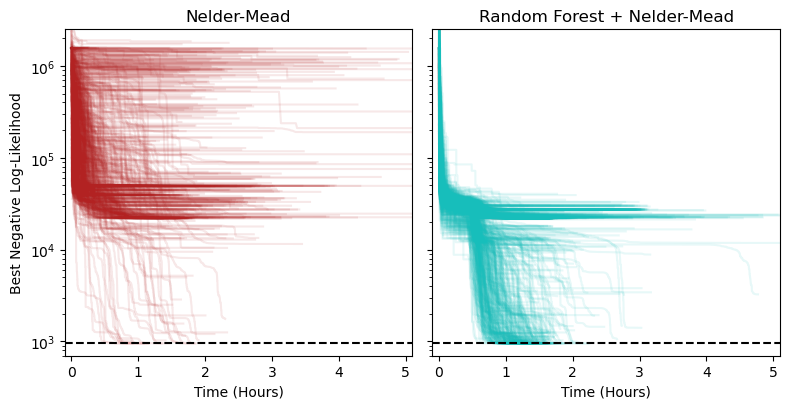

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4.2), sharex=True, sharey=True)

n_runs = 900
alpha = 0.1

# Nelder-Mead + Nelder-Mead
id = 0
for i in range(n_runs):
    ax[id].plot(np.array(nm_nm_times[i])/3600, nm_nm_best_loss[i], color="#b22222", alpha=alpha)

ax[id].axhline(y=true_loss, color = "black", linestyle = "--", label = "True Loss")
ax[id].set_xlim(-0.1, 5.1)
ax[id].set_ylim(7*1e2, 2.5*1e6)
ax[id].set_yscale("log")
ax[id].set_xlabel("Time (Hours)")
ax[id].set_ylabel("Best Negative Log-Likelihood")
ax[id].set_title("Nelder-Mead")

# Random Forest + Nelder-Mead
id = 1
for i in range(n_runs):
    ax[id].plot(np.array(rf_nm_times[i])/3600, rf_nm_best_loss[i], color="#17BEBB", alpha=alpha)

ax[id].axhline(y=true_loss, color = "black", linestyle = "--", label = "True Loss")
ax[id].set_yscale("log")
ax[id].set_xlabel("Time (Hours)")
ax[id].set_title("Random Forest + Nelder-Mead")

fig.tight_layout()

plt.savefig("figures/S3 Fig.tif", dpi=300, bbox_inches="tight")

In [41]:
all_nm_nm_losses_6 = []
all_nm_nm_times_6 = []
all_nm_nm_best_x_6 = []
all_rf_nm_losses_6 = []
all_rf_nm_times_6 = []
all_rf_nm_best_x_6 = []

n_hours = 100

for i in tqdm(range(2000)):

    losses, times, best_x = sample_best_fixed_time_budget(nm_nm_times, nm_nm_best_loss, nm_nm_best_x, n_hours*3600)
    all_nm_nm_losses_6.append(losses)
    all_nm_nm_times_6.append(times)
    all_nm_nm_best_x_6.append(best_x)

    losses, times, best_x = sample_best_fixed_time_budget(rf_nm_times, rf_nm_best_loss, rf_nm_best_x, n_hours*3600)
    all_rf_nm_losses_6.append(losses)
    all_rf_nm_times_6.append(times)
    all_rf_nm_best_x_6.append(best_x)

100%|██████████| 2000/2000 [01:52<00:00, 17.83it/s]


In [42]:
# get time series overlaps
time_min = max(max(times[0] for times in all_nm_nm_times_6), max(times[0] for times in all_rf_nm_times_6))
time_max = min(min(times[-1] for times in all_nm_nm_times_6), min(times[-1] for times in all_rf_nm_times_6))
time_grid_6 = np.arange(time_min, time_max + 1e-6, 10.0)

# interpolate each trajectory - NM+NM
all_nm_nm_interp_losses_6 = []
for time, loss in zip(all_nm_nm_times_6, all_nm_nm_losses_6):
    interp_losses = np.interp(time_grid_6, time, loss, left=np.nan, right=np.nan)
    all_nm_nm_interp_losses_6.append(interp_losses)
all_nm_nm_interp_losses_6 = np.array(all_nm_nm_interp_losses_6)

# interpolate each trajectory - RF+NM
all_rf_nm_interp_losses_6 = []
for time, loss in zip(all_rf_nm_times_6, all_rf_nm_losses_6):
    interp_losses = np.interp(time_grid_6, time, loss, left=np.nan, right=np.nan)
    all_rf_nm_interp_losses_6.append(interp_losses)
all_rf_nm_interp_losses_6 = np.array(all_rf_nm_interp_losses_6)

# compute medians + quantiles
nm_nm_median_6 = np.nanmedian(all_nm_nm_interp_losses_6, axis=0)
nm_nm_q_low_6, nm_nm_q_high_6 = np.nanquantile(all_nm_nm_interp_losses_6, [0.025, 0.975], axis=0)
rf_nm_median_6 = np.nanmedian(all_rf_nm_interp_losses_6, axis=0)
rf_nm_q_low_6, rf_nm_q_high_6 = np.nanquantile(all_rf_nm_interp_losses_6, [0.025, 0.975], axis=0)

In [43]:
def success_prop(sampled_losses, true_loss):
    return np.sum(sampled_losses < true_loss) / len(sampled_losses)

nm_nm_success_prop_6 = [success_prop(losses, true_loss) for losses in all_nm_nm_interp_losses_6.T]
rf_nm_success_prop_6 = [success_prop(losses, true_loss) for losses in all_rf_nm_interp_losses_6.T]

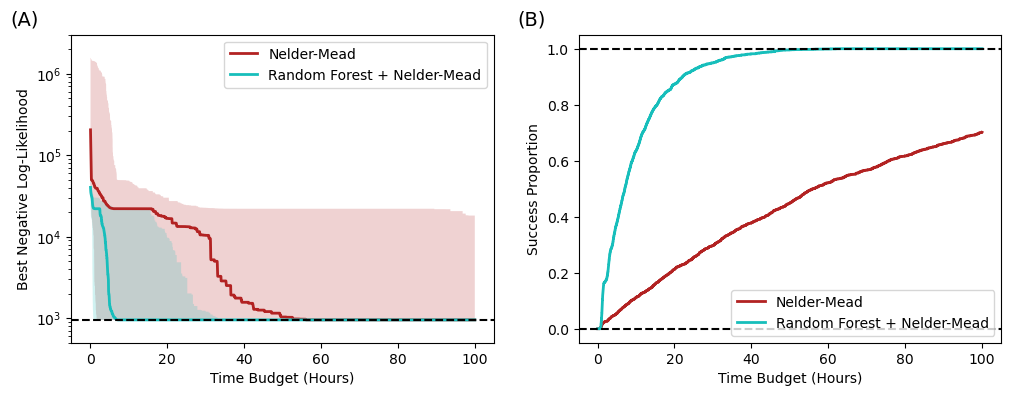

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

alpha = 0.2
linewidth = 2

# Nelder-Mead + Nelder-Mead
ax[0].plot(time_grid_6/3600, nm_nm_median_6, color="#b22222", linewidth=linewidth, label="Nelder-Mead")
ax[0].fill_between(time_grid_6/3600, nm_nm_q_low_6, nm_nm_q_high_6, color="#b22222", alpha=alpha, edgecolor=None)

# Random Forest + Nelder-Mead
ax[0].plot(time_grid_6/3600, rf_nm_median_6, color="#17BEBB", linewidth=linewidth, label="Random Forest + Nelder-Mead")
ax[0].fill_between(time_grid_6/3600, rf_nm_q_low_6, rf_nm_q_high_6, color="#17BEBB", alpha=alpha, edgecolor=None)

ax[0].axhline(y=true_loss, color = "black", linestyle = "--")

ax[0].set_ylim(500, 3*10**6)
ax[0].set_xlabel("Time Budget (Hours)")
ax[0].set_ylabel("Best Negative Log-Likelihood")
ax[0].set_yscale("log")
ax[0].legend(loc="upper right")

ax[1].plot(time_grid_6/3600, nm_nm_success_prop_6, color="#b22222",
         linewidth=linewidth, label="Nelder-Mead")
ax[1].plot(time_grid_6/3600, rf_nm_success_prop_6, color="#17BEBB",
         linewidth=linewidth, label="Random Forest + Nelder-Mead")

ax[1].axhline(y=0.0, color="black", linestyle="--")
ax[1].axhline(y=1.0, color="black", linestyle="--")

ax[1].set_xlabel("Time Budget (Hours)")
ax[1].set_ylabel("Success Proportion")
ax[1].legend(loc="lower right")

ax[0].text(-0.145, 1.02, "(A)", transform=ax[0].transAxes,
           ha="left", va="bottom", fontsize=14)

ax[1].text(-0.145, 1.02, "(B)", transform=ax[1].transAxes,
           ha="left", va="bottom", fontsize=14)

plt.savefig("figures/Fig6.tif", dpi=300, bbox_inches="tight")